# 🏋️ Akıllı Egzersiz Sınıflandırma ve İçerik Tabanlı Öneri Sistemi

Bu çalışma, **1.324 fitness egzersizi** içeren veri seti üzerinde Makine Öğrenmesi (Sınıflandırma) ve Metin Benzerliği (İçerik Tabanlı Öneri Sistemi) kullanılarak hazırlanmış sade bir bilgisayar mühendisliği öğrencisi projesidir.

### 📌 Proje İki Ana Bölümden Oluşmaktadır:
1. **Bölüm 1: Egzersiz Sınıflandırma (Supervised Learning)**
   - Egzersiz adı ve talimat metinlerinden hedef vücut bölgesini (`category`) tahmin etme.
   - Yöntemler: **TF-IDF**, **Logistic Regression**, **Random Forest**, **KNN**.
2. **Bölüm 2: İçerik Tabanlı Öneri Sistemi (Content-Based Recommendation)**
   - TF-IDF vektörleri ve **Cosine Similarity** kullanarak seçilen bir egzersize en çok benzeyen alternatif 3 egzersizi önerme.


In [1]:
# 1. Veri Setinin İndirilmesi ve Yüklenmesi
import json
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# GitHub'dan 1.324 egzersizlik veriyi indirme
url = "https://raw.githubusercontent.com/hasaneyldrm/exercises-dataset/main/data/exercises.json"
urllib.request.urlretrieve(url, "exercises.json")

# JSON verisini yükleme ve DataFrame'e dönüştürme
with open("exercises.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Egzersiz adı ve İngilizce talimatları birleştirme
def get_instruction_en(inst):
    if isinstance(inst, dict):
        return inst.get("en", "")
    elif isinstance(inst, list):
        return " ".join(inst)
    return str(inst)

df["clean_instructions"] = df["instructions"].apply(get_instruction_en)
df["text_data"] = df["name"].fillna("") + " " + df["clean_instructions"].fillna("")

print("Toplam Egzersiz Sayısı:", len(df))
df[['id', 'name', 'category', 'equipment']].head()


Toplam Egzersiz Sayısı: 1324


,id,name,category,equipment
0,0001,3/4 sit-up,waist,body weight
1,0002,45° side bend,waist,body weight
2,0003,air bike,waist,body weight
3,1512,all fours squad stretch,upper legs,body weight
4,0006,alternate heel touchers,waist,body weight


/tmp/ipykernel_1675/3136746309.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="category", data=df, order=df["category"].value_counts().index, palette="viridis")


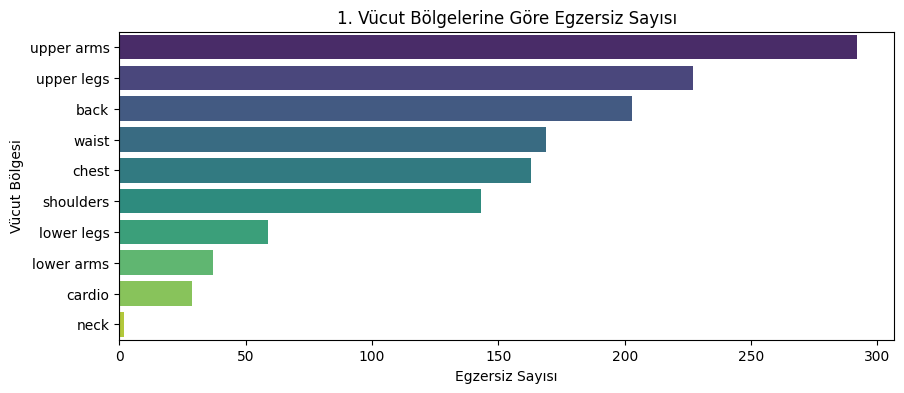

/tmp/ipykernel_1675/3136746309.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_equipment.values, y=top_equipment.index, palette="mako")


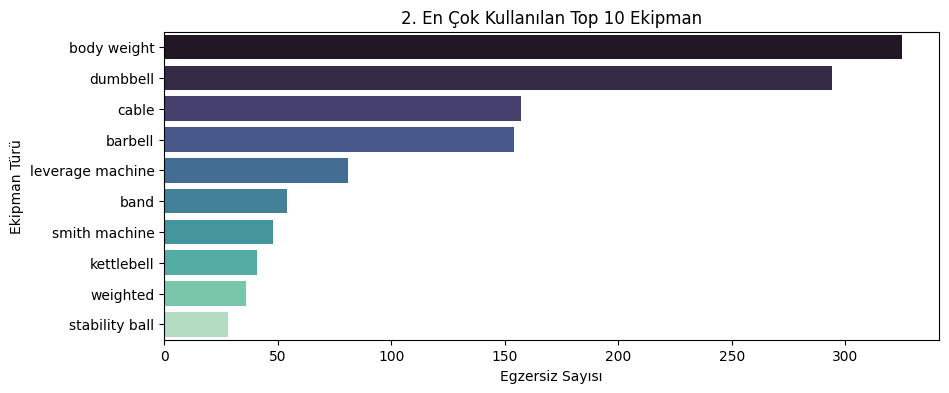

🏋️ Body Weight (Vücut Ağırlığı) Egzersiz Sayısı: 325 (Oran: %24.5)


In [2]:
# 2. Keşifçi Veri Analizi (EDA)

# Vücut Bölgesi Dağılımı
plt.figure(figsize=(10, 4))
sns.countplot(y="category", data=df, order=df["category"].value_counts().index, palette="viridis")
plt.title("1. Vücut Bölgelerine Göre Egzersiz Sayısı")
plt.xlabel("Egzersiz Sayısı")
plt.ylabel("Vücut Bölgesi")
plt.show()

# En Çok Kullanılan Ekipmanlar
plt.figure(figsize=(10, 4))
top_equipment = df["equipment"].value_counts().head(10)
sns.barplot(x=top_equipment.values, y=top_equipment.index, palette="mako")
plt.title("2. En Çok Kullanılan Top 10 Ekipman")
plt.xlabel("Egzersiz Sayısı")
plt.ylabel("Ekipman Türü")
plt.show()

# Body Weight Egzersiz Analizi
bodyweight_count = (df["equipment"].str.lower() == "body weight").sum()
print(f"🏋️ Body Weight (Vücut Ağırlığı) Egzersiz Sayısı: {bodyweight_count} (Oran: %{bodyweight_count/len(df)*100:.1f})")


In [4]:
# 3. Metin İşleme (TF-IDF) ve Veri Bölme

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Metin verilerini 500 boyutlu TF-IDF matrisine dönüştürme
tfidf = TfidfVectorizer(max_features=500, stop_words="english")
X_text = tfidf.fit_transform(df["text_data"]).toarray()
y = df["category"]

# Veriyi %80 Eğitim, %20 Test olarak ayırma
X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Eğitim Kümesi (Train): {X_train.shape[0]} egzersiz")
print(f"Test Kümesi (Test): {X_test.shape[0]} egzersiz")


Eğitim Kümesi (Train): 1059 egzersiz
Test Kümesi (Test): 265 egzersiz


In [5]:
# 4. BÖLÜM 1: Egzersiz Sınıflandırma Modelleri

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []
rf_pred = None

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted")

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

    if name == "Random Forest":
        rf_pred = y_pred

results_df = pd.DataFrame(results)
print("📊 MODEL PERFORMANS KARŞILAŞTIRMA TABLOSU:")
display(results_df)


📊 MODEL PERFORMANS KARŞILAŞTIRMA TABLOSU:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8604,0.8687,0.8604,0.8557
1,Random Forest,0.8528,0.8567,0.8528,0.8515
2,KNN,0.7434,0.7567,0.7434,0.7456


/tmp/ipykernel_1675/658362332.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x="Model", y="Accuracy", data=results_df, palette="Set2")


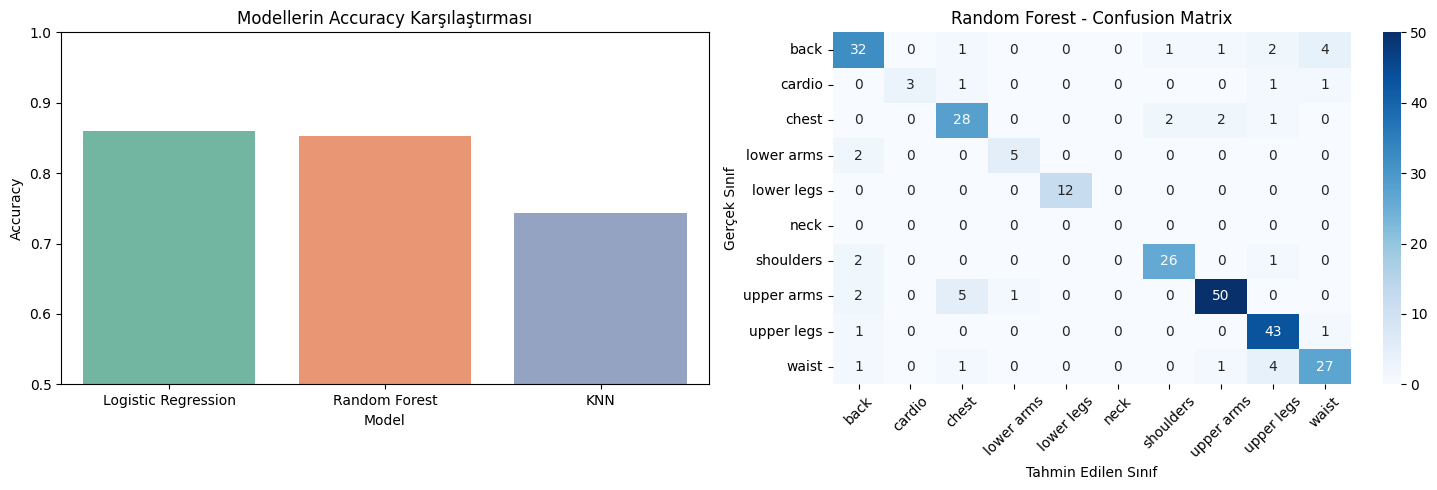

In [6]:
# 5. Görsel Değerlendirme (Accuracy Grafiği & Confusion Matrix)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Model Accuracy Grafiği
sns.barplot(ax=axes[0], x="Model", y="Accuracy", data=results_df, palette="Set2")
axes[0].set_title("Modellerin Accuracy Karşılaştırması")
axes[0].set_ylim(0.5, 1.0)

# 2. Random Forest Confusion Matrix
categories = sorted(y.unique())
cm = confusion_matrix(y_test, rf_pred, labels=categories)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=categories, yticklabels=categories)
axes[1].set_title("Random Forest - Confusion Matrix")
axes[1].set_xlabel("Tahmin Edilen Sınıf")
axes[1].set_ylabel("Gerçek Sınıf")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [7]:
# 6. BÖLÜM 2: İçerik Tabanlı Egzersiz Öneri Sistemi (Cosine Similarity)

from sklearn.metrics.pairwise import cosine_similarity

# Egzersiz TF-IDF vektörleri arasındaki kosinüs benzerliği matrisi
similarity_matrix = cosine_similarity(X_text)

def get_recommendations(exercise_name, top_n=3):
    matches = df[df["name"].str.lower().str.contains(exercise_name.lower(), na=False)]
    if len(matches) == 0:
        print(f"❌ '{exercise_name}' adında egzersiz bulunamadı.")
        return None

    idx = matches.index[0]
    target_exercise = df.iloc[idx]

    sim_scores = list(enumerate(similarity_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Kendisi hariç en benzer top_n egzersizi seçme
    recommended_indices = [i[0] for i in sim_scores if i[0] != idx][:top_n]

    recs = df.iloc[recommended_indices][["name", "category", "equipment"]].copy()
    recs["Benzerlik Skoru"] = [f"%{sim_scores[i][1]*100:.1f}" for i in recommended_indices]

    print(f"🎯 Seçilen Egzersiz: {target_exercise['name']} (Kategori: {target_exercise['category']})")
    return recs

# Demo 1: Bench Press için öneriler
print("--- 1. Barbell Bench Press Alternatifleri ---")
display(get_recommendations("bench press", top_n=3))

print("\n--- 2. Squat Alternatifleri ---")
display(get_recommendations("squat", top_n=3))


--- 1. Barbell Bench Press Alternatifleri ---
🎯 Seçilen Egzersiz: band bench press (Kategori: chest)


,name,category,equipment,Benzerlik Skoru
473,dumbbell bench press,chest,dumbbell,%15.7
1086,resistance band seated chest press,chest,resistance band,%6.8
136,barbell jm bench press,upper arms,barbell,%26.5



--- 2. Squat Alternatifleri ---
🎯 Seçilen Egzersiz: band one arm single leg split squat (Kategori: upper legs)


,name,category,equipment,Benzerlik Skoru
79,band single leg split squat,upper legs,band,%29.2
198,barbell single leg split squat,upper legs,barbell,%20.1
699,dumbbell single leg squat,upper legs,dumbbell,%9.0
